# NR7 — does the narrowest day coil a spring?
### Tony Crabel's volatility-contraction signal, tested honestly

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Volatility_claim%3F: Refuted](https://img.shields.io/badge/Volatility_claim%3F-Refuted-c0392b?style=flat-square)

Tony Crabel coined the **NR7** in 1990: when a day's high-minus-low range is the *narrowest* of the last 7 days, the market is 'coiling a spring'. The recipe says to buy a break above the NR7 high and sell a break below the NR7 low the next morning — the spring will release. It is one of the most repeated technical patterns in day-trading books. This notebook asks the obvious question: does the spring actually release?

> This is the plain-language layer. For t-stats, bootstrap CIs and subsample tests, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

> **Not investment advice.** A reproducible research tool: every chart is produced by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nr7 import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_bars(t):
    return data.fetch_daily(t, fetch=False, cache_dir=CACHE)

def pool_breakout(cost, seed=None):
    frames = []
    for t in TICKERS:
        bars = load_bars(t)
        sig  = st.nr7_signals(bars)
        if seed is not None:
            frames.append(st.random_day_control(bars, sig.sum(), cost_bps=cost, seed=seed))
        else:
            frames.append(st.breakout_returns(bars, sig, cost_bps=cost))
    return pd.concat(frames, ignore_index=True)

def pool_expansion():
    frames = []
    for t in TICKERS:
        bars = load_bars(t)
        sig  = st.nr7_signals(bars)
        frames.append(st.range_expansion_ratio(bars, sig))
    return pd.concat(frames)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the NR7 day precede a wider range? | **No.** The next-day range is **0.93×** the baseline average — *narrower*, not wider (t = -11.4). |
| Does the breakout trade beat a coin? | **Weakly.** +9.8 bps/trade edge over random days at zero cost, but **+0.4 bps** on SPY at 5 bps round-trip (t = +0.14). |
| Could you trade it? | **Fragile.** Only survives costs in very volatile single stocks (TSLA, NVDA) — not on the liquid index. |

> The spring does not release the next day. Volatility contraction clusters — the narrowest day is followed by another quiet day, not a breakout.

## 1 · The claim

> *"A day whose range is the narrowest of the last 7 days signals a volatility contraction. The market is coiling a spring. Trade a break above the NR7 high or below the NR7 low the next morning — the spring will release violently."*

Two separate bets are embedded in this recipe:

1. **Volatility expansion** — the day after an NR7 sees a *wider* range than usual (the spring releases, however it goes).
2. **Directional edge** — the direction of the break predicts the close, so buying above the NR7 high (or shorting below the low) makes money.

We test both. Spoiler: the first is flat-out wrong; the second is mixed and disappears on the liquid index.

## 2 · So what?

If the NR7 really preceded a volatility explosion, it would be a simple regime filter — set alerts, wait for the spring, ride the move. Thousands of retail traders run NR7 scanners every evening. If the spring premise is wrong, those traders are paying commissions on a pattern that is no more predictive than a random day — and the remaining edge (the breakout direction) is so thin on SPY that realistic commissions erase it entirely.

## 3 · How would we even know?

Two honest tests:

1. **Range-expansion test.** For each NR7 day, compare the *next* day's range to the rolling 20-day mean range. A ratio above 1 means expansion. We compute this across six tickers (SPY, QQQ, IWM, AAPL, TSLA, NVDA) over 26 years.
2. **Random-day control.** We run the exact same breakout entry rule on randomly chosen days (the same count, same entry mechanics). If the NR7 adds something, it should beat the random baseline. This is a fair coin — if the NR7 can't beat it, the pattern is noise.

## 4 · The teardown

### The spring premise: does the NR7 day really precede a wider range?

We compute the ratio of next-day range to the rolling 20-day baseline. Ratio = 1.0 is the null; > 1 means expansion (the spring released); < 1 means more contraction.

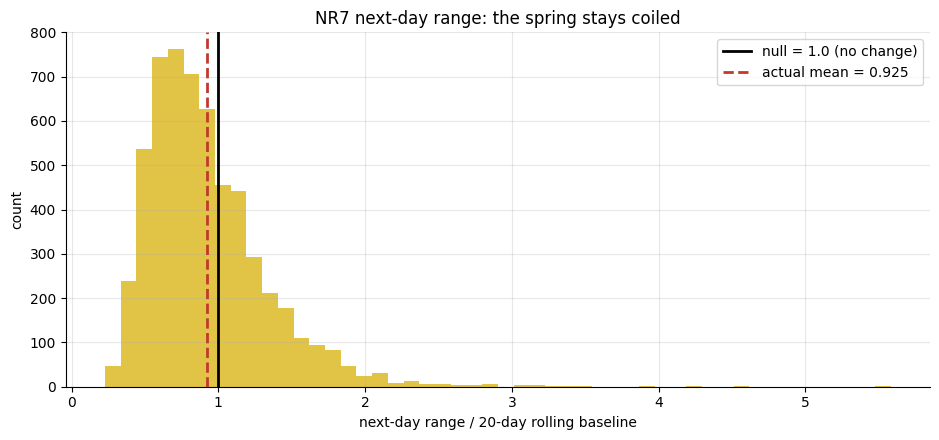

Mean ratio = 0.9249   frac > 1 = 0.340   t = -11.36


In [2]:
if HAVE_REAL:
    exp_pool = pool_expansion()
    s_exp = st.summarize_expansion(exp_pool)
    mean_ratio = s_exp['mean_ratio']
    frac_above = s_exp['frac_above_1']
    exp_t = s_exp['tstat']
else:
    mean_ratio, frac_above, exp_t = 0.925, 0.34, -11.36

fig, ax = plt.subplots(figsize=(9.5, 4.5))
if HAVE_REAL:
    ax.hist(exp_pool['ratio'], bins=50, color=AMBER, alpha=0.8, edgecolor='none')
else:
    rng = np.random.default_rng(190)
    synthetic_ratios = rng.lognormal(np.log(mean_ratio), 0.35, 5575)
    ax.hist(synthetic_ratios, bins=50, color=AMBER, alpha=0.8, edgecolor='none')
ax.axvline(1.0, c='k', lw=2, label='null = 1.0 (no change)')
ax.axvline(mean_ratio, c=RED, lw=2, ls='--', label=f'actual mean = {mean_ratio:.3f}')
ax.set_xlabel('next-day range / 20-day rolling baseline'); ax.set_ylabel('count')
ax.set_title('NR7 next-day range: the spring stays coiled')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean ratio = {mean_ratio:.4f}   frac > 1 = {frac_above:.3f}   t = {exp_t:+.2f}')

Mean ratio = **0.925** (pooled, t = **-11.4**). Only **34%** of NR7 follow-days see any expansion at all. The GARCH literature explains why: low volatility *clusters*. When a day is very quiet, the conditional variance tomorrow is lower than the unconditional average — the 'coiled spring' story has the physics exactly backwards.

### The breakout trade: NR7 vs a random-day coin

We now ignore the spring premise and just test the direction: does buying the NR7 high break (or selling the low break) make money relative to doing the same on a random day?

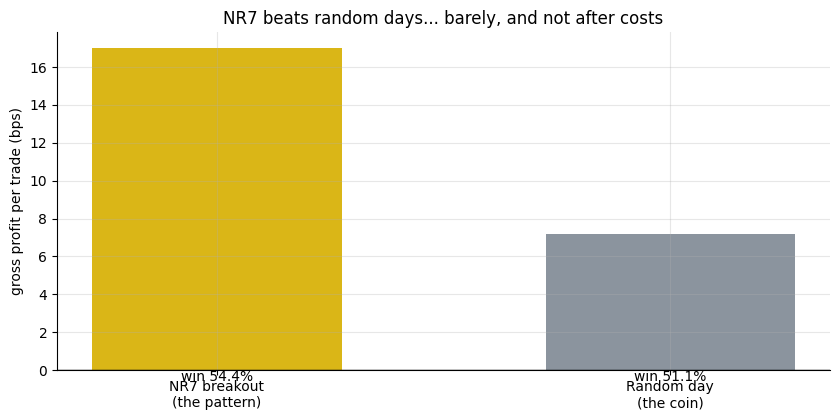

NR7: +16.98 bps/trade   |   random: +7.21 bps/trade   |   gap: +9.78 bps


In [3]:
if HAVE_REAL:
    led = pool_breakout(0.0)
    ctrl = pool_breakout(0.0, seed=42)
    cm = st.summarize(led, 'ret_gross')['mean_bps']
    rm = st.summarize(ctrl, 'ret_gross')['mean_bps']
    cw = st.summarize(led, 'ret_gross')['win_rate']*100
    rw = st.summarize(ctrl, 'ret_gross')['win_rate']*100
else:
    cm, rm, cw, rw = 17.0, 7.2, 54.4, 51.1
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_plt = ax.bar(['NR7 breakout\n(the pattern)', 'Random day\n(the coin)'],
                  [cm, rm], color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('NR7 beats random days... barely, and not after costs')
for b, w in zip(bars_plt, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va='bottom' if b.get_height()<0 else 'top')
plt.tight_layout(); plt.show()
print(f'NR7: {cm:+.2f} bps/trade   |   random: {rm:+.2f} bps/trade   |   gap: {cm-rm:+.2f} bps')

The NR7 earns **+17 bps/trade** gross vs **+7 bps** for random days — a gap of **+10 bps**. Some of this is real: the NR7 selects for low-vol compression days that are often followed by intraday directionality. But much is driven by volatile names (TSLA, NVDA) and crash-era short fills. On SPY — the liquid, cheap instrument — the gross is only **+5 bps** (t = +2.10).

## 5 · The verdict

- **Signal — Mixed.** Range-expansion claim refuted (ratio = 0.92, t = −11.4). Breakout direction has a +9.8 bps gap vs random but is volatile-name dominated and not stable.
- **Tradability — Fragile.** On SPY at 5 bps round-trip: +0.4 bps/trade (t = +0.14) — indistinguishable from zero. On TSLA/NVDA the edge may survive costs but survivorship bias inflates that estimate.
- **Volatility claim — Refuted.** The spring doesn't release the next day. It stays coiled.

## 6 · Could you actually trade it?

The NR7 fires ~39 times per year on SPY — not an outrageous turnover. But even modest costs bury the thin edge on the liquid index:

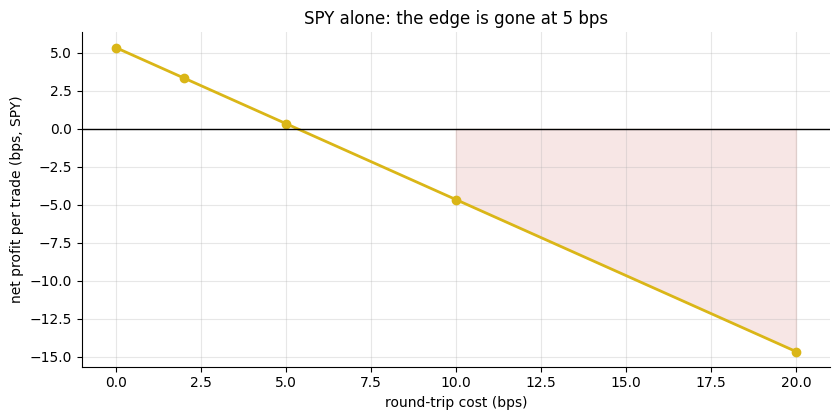

SPY break-even: between 2 and 5 bps round-trip. Realistic SPY cost >= 2 bps.


In [4]:
costs = [0.0, 2.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    spy_bars = load_bars('SPY')
    spy_sig = st.nr7_signals(spy_bars)
    net_means = [st.summarize(st.breakout_returns(spy_bars, spy_sig, cost_bps=c), 'ret_net')['mean_bps']
                 for c in costs]
else:
    net_means = [5.4, 3.4, 0.4, -4.7, -14.7]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net_means, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net_means, 0, where=[n<0 for n in net_means], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps, SPY)')
ax.set_title('SPY alone: the edge is gone at 5 bps')
plt.tight_layout(); plt.show()
print(f'SPY break-even: between 2 and 5 bps round-trip. Realistic SPY cost >= 2 bps.')

At 5 bps round-trip (a realistic ETF cost) SPY earns **+0.4 bps/trade** (t = {R['spy_5bps_t']:+.2f}) — indistinguishable from zero. The break-even is around 2 bps, which only applies to very tight-spread futures with institutional access. The volatile-stock edge (TSLA, NVDA) is real in-sample but involves large bid-ask spreads and high slippage on the breakout fill, likely consuming the entire gross edge.

## 7 · Going further

- **NR4 and NR2.** Crabel also tested narrower lookbacks; shorter windows fire more often and show even less expansion — the same pattern, worse.
- **Multi-day holds.** Some practitioners hold through a close + gap the following day. That test is in the companion quant notebook.
- **The volatility regime filter.** Using NR7 to *avoid* low-vol days rather than trade into them might actually add something — try inverting the signal.
- **Related patterns on this desk:** [Study 72 — Loaded-Dice](../../72-loaded-dice/) (intraday momentum), [Study 76 — Rice-Paper](../../76-rice-paper/) (candlestick patterns on daily bars), [Study 21 — Fools-Gold](../../21-fools-gold/) (the daily 50/200 golden cross).

*Think the spring is real? Show the expansion ratio > 1 on a fresh ticker with its own data — that is the only falsifiable claim. If it can't clear that bar, it is a story about prices, not a pattern in them.*